# Opik Metrics Explorer

Notebook para carregar traces e threads do Opik, escolher colunas/metricas e calcular agregacoes.

Baseado na API oficial do SDK:
- `client.search_traces(project_name=..., filter_string=..., max_results=..., truncate=..., exclude=...)`
- `client.search_threads(project_name=..., filter_string=..., max_results=..., truncate=...)`
- `client.log_threads_feedback_scores(scores=[...], project_name=...)` para feedback por thread

Os filtros suportam campos como `thread_id`, `tags`, `metadata.*`, `feedback_scores.*`, `usage.*`, `duration` e outros.

In [165]:
import os
os.environ["OPIK_API_KEY"] = "fvgscIEntSdxGOAxp6CLhjIVa"
os.environ["OPIK_WORKSPACE"] = "aasmagroup23"
os.environ["OPIK_PROJECT_NAME"] = "ChatDev-AASMA"

!pip install opik pandas -q

In [166]:
from __future__ import annotations

import os
from typing import Any, Iterable

import pandas as pd

try:
    from opik import Opik
except Exception as exc:
    raise RuntimeError("The opik package is required in this environment.") from exc

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', 200)

In [167]:
PROJECT_NAME = os.getenv('OPIK_PROJECT_NAME', 'ChatDev')
OPIK_HOST = os.getenv('OPIK_URL_OVERRIDE', 'https://www.comet.com/opik/api')
OPIK_WORKSPACE = os.getenv('OPIK_WORKSPACE') or os.getenv('OPIK_WORKSPACE_NAME')
OPIK_API_KEY = os.getenv('OPIK_API_KEY')

client = Opik(
    project_name=PROJECT_NAME,
    host=OPIK_HOST,
    workspace=OPIK_WORKSPACE,
    api_key=OPIK_API_KEY,
)

PROJECT_NAME

'ChatDev-AASMA'

In [168]:
def flatten_dict(value: dict[str, Any], prefix: str = '', sep: str = '.') -> dict[str, Any]:
    items: dict[str, Any] = {}
    for key, item in value.items():
        new_key = f'{prefix}{sep}{key}' if prefix else key
        if isinstance(item, dict):
            items.update(flatten_dict(item, new_key, sep=sep))
        else:
            items[new_key] = item
    return items

def pick_fields(record: Any, fields: Iterable[str]) -> dict[str, Any]:
    data: dict[str, Any] = {}
    for field in fields:
        value = record
        for part in field.split('.'):
            if value is None:
                break
            if isinstance(value, dict):
                value = value.get(part)
            else:
                value = getattr(value, part, None)
        data[field] = value
    return data

def as_dict(record: Any) -> dict[str, Any]:
    if isinstance(record, dict):
        return record
    if hasattr(record, 'model_dump'):
        return record.model_dump()
    if hasattr(record, 'dict'):
        return record.dict()
    return {k: getattr(record, k) for k in dir(record) if not k.startswith('_')}

In [169]:
def fetch_traces(
    filter_string: str | None = None,
    max_results: int = 1000,
    truncate: bool = False,
    exclude: list[str] | None = None,
) -> pd.DataFrame:
    traces = client.search_traces(
        project_name=PROJECT_NAME,
        filter_string=filter_string,
        max_results=max_results,
        truncate=truncate,
        exclude=exclude,
    )
    rows = [as_dict(trace) for trace in traces]
    return pd.json_normalize(rows, sep='.') if rows else pd.DataFrame()

def fetch_threads(
    filter_string: str | None = None,
    max_results: int = 1000,
    truncate: bool = False,
) -> pd.DataFrame:
    threads = client.search_threads(
        project_name=PROJECT_NAME,
        filter_string=filter_string,
        max_results=max_results,
        truncate=truncate,
    )
    rows = [as_dict(thread) for thread in threads]
    return pd.json_normalize(rows, sep='.') if rows else pd.DataFrame()

In [170]:
trace_df = fetch_traces(max_results=2000, truncate=False)
thread_df = fetch_threads(max_results=2000, truncate=False)

print('Trace columns:', list(trace_df.columns))
print('Thread columns:', list(thread_df.columns))

if not trace_df.empty:
    print('\nSample trace row (first):')
    print(trace_df.iloc[0].to_dict())

def nested_keys(df: pd.DataFrame, col: str) -> list[str]:
    keys = set()
    if col in df.columns:
        for value in df[col].dropna():
            if isinstance(value, dict):
                keys.update(value.keys())
    return sorted(keys)

print('\nTrace feedback_score keys:', nested_keys(trace_df, 'feedback_scores'))
print('Trace metadata keys:', nested_keys(trace_df, 'metadata'))
print('\nThread feedback_score keys:', nested_keys(thread_df, 'feedback_scores'))


import datetime
from typing import List, Dict, Any

def extract_scores(feedback_scores: List[Dict[str, Any]]) -> List[Dict[str, Any]]:
    """
    Extract name, value, and justification (reason) from each feedback score.

    Args:
        feedback_scores: A list of dictionaries, each representing a score.
                         Expected keys: 'name', 'value', 'reason'.

    Returns:
        A list of dictionaries, each containing:
            - 'name': str
            - 'value': float or int
            - 'justification': str (the 'reason' field)
    """
    extracted = []
    for score in feedback_scores:
        extracted.append({
            'name': score.get('name', ''),
            'value': score.get('value', None),
            'justification': score.get('reason', '')  # 'reason' is the justification
        })
    return extracted

Trace columns: ['id', 'project_id', 'name', 'start_time', 'end_time', 'input', 'output', 'tags', 'error_info', 'usage', 'created_at', 'last_updated_at', 'created_by', 'last_updated_by', 'feedback_scores', 'span_feedback_scores', 'comments', 'guardrails_validations', 'total_estimated_cost', 'span_count', 'duration', 'ttft', 'thread_id', 'visibility_mode', 'llm_span_count', 'has_tool_spans', 'providers', 'experiment', 'source', 'environment', 'metadata.node_id', 'metadata.agent_role', 'metadata.provider', 'metadata.model', 'metadata.sender_ids', 'metadata.receiver_id', 'metadata.run_id', 'metadata.providers', 'usage.completion_tokens', 'usage.original_usage.completion_tokens', 'usage.original_usage.completion_tokens_details.audio_tokens', 'usage.original_usage.completion_tokens_details.image_tokens', 'usage.original_usage.completion_tokens_details.reasoning_tokens', 'usage.original_usage.is_byok', 'usage.original_usage.prompt_tokens', 'usage.original_usage.prompt_tokens_details.audio_tok

In [171]:
import pandas as pd
from typing import Any

TRACE_COLUMNS = [
    'id', 'name', 'tags', 'thread_id',
    'metadata.node_id', 'metadata.sender_ids', 'feedback_scores',
    'span_count', 'duration', 'usage.prompt_tokens', 'usage.total_tokens',
]

THREAD_COLUMNS = [
    'id', 'status', 'duration', 'number_of_messages',
    'created_at', 'last_updated_at', 'feedback_scores', 'tags',
]

def select_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    keep = [col for col in columns if col in df.columns]
    return df.loc[:, keep].copy() if keep else df.copy()

def extract_feedback_scores(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, trace in df.iterrows():
        scores = trace.get('feedback_scores')
        if not isinstance(scores, list):
            continue
        for score in scores:
            if not isinstance(score, dict):
                continue
            rows.append({
                'trace_id': trace.get('id'),
                'thread_id': trace.get('thread_id'),
                'node_id': trace.get('metadata.node_id'),
                'score_name': score.get('name'),
                'score_value': score.get('value'),
                'score_reason': score.get('reason'),
            })
    scores_df = pd.DataFrame(rows)
    if not scores_df.empty:
        scores_df['score_value'] = pd.to_numeric(scores_df['score_value'], errors='coerce')
    return scores_df

# Fetch
traces_raw = fetch_traces(max_results=2000, truncate=False)
threads_raw = fetch_threads(max_results=2000, truncate=False)

trace_df = select_columns(traces_raw, TRACE_COLUMNS)
thread_df = select_columns(threads_raw, THREAD_COLUMNS)
feedback_df = extract_feedback_scores(trace_df)

# Mapeamento dos grupos (mantendo os nomes originais com _1, _2, _3)
thread_groups = {
    'client_liaison_run_1': [
        'c629ba35-e4ba-4a1e-b72d-acd350e739d9',
        'ea708e64-6003-4e24-8690-71db753d13f8',
        '2297d6fc-6432-4686-9553-0d19b5ab3d97',
        '9f877593-8e80-4bbf-8179-caa1886cdfdc',
        'd72eda67-643a-4361-aa8e-839a6df93624'
    ],
    'client_liaison_run_2': [
        '738bbc70-f060-4324-ba4b-ef2047771333',
        '8318b44c-288f-4e9d-9599-dc6be3a9c64b',
        '8faf0163-7d38-437d-a84d-9e0974a2d542',
        'd53c91ba-38fb-4704-942e-ac17bf23909c',
        '64f20dae-a7f5-4927-824b-61198103a26e'
    ],
    'client_liaison_run_3': [
        'a404c68f-9395-4412-b4f4-022013abcbe8',
        '95db105e-6e92-4e41-b4fd-b73eba9887e7',
        '4c7a7b65-f852-461e-b2bf-2bdaff50c334',
        'a2a0dfcb-76e1-4de6-8ebc-4077d222bbaf',
        '2c858a77-419e-4931-a6c7-ab2c7fa4cd59'
    ],
    'client_liaison_run_4': [
        'ef06882a-2679-41a8-884b-f8974b0609c9',
        'facd7f24-2191-447a-89d2-545f38cdfe29',
        'ad6878bc-8697-41e6-802e-1d50a15066de',
        '7b7c55f7-7267-4b57-82d8-ee8b595fbd84',
        'ac80fc19-24c9-4942-a486-1fa061f2a176'
    ],

    'client_liaison_run_5': [
        'a3e186b3-2aac-4a26-9391-4e4c926f05ff',
        '050a6bdc-6c14-4b0e-a059-8a4d406558fd',
        '74f97aca-a3f9-4f23-b7b3-a8c1210becb6',
        '3d73e911-705c-481d-90e9-c49a23f6d3b3',
        'fbbc6921-ecaf-48e9-ba98-0c0582af10ae'
    ],

    'original_run_1': [
        'd4df6e7c-283e-425a-be5d-c62e6da57870',
        'd77d9d99-e64b-44b6-b949-d107c99f6403',
        '0f0ca6d8-cdf9-4e67-991d-20ed2a621166',
        '52df482c-3ec1-480f-8fd1-6f541c0bccfd',
        '94120fc0-a8e6-4894-a7e1-48c2833afc3e'
    ],
    'original_run_2': [
        '859e0bd9-a02e-4d94-97c7-83738fd26ce6',
        '77700587-8aa3-43f6-8100-24e834ba7b38',
        '8f8629df-7631-46d5-a636-173127fc7040',
        '9ce35d91-0e5b-4b29-ab11-04414d0e3a2c',
        '37af9b32-161c-4ac3-a452-67e78f53cb12'
    ],
    'original_run_6': [
        'fff549e8-1b39-4867-9926-b16a90059bb7',
        'fc94b9a0-9634-446f-9318-95f815363653',
        '951e5e66-3acc-42c7-b9c0-857bc3774789',
        '454e2149-8c00-40f7-ae31-2d0f51f276a4',
        'f1c7f810-4021-4898-a500-213ee03593d0'
    ],

    'original_run_4': [
        '999875b3-1945-441a-bcfa-387467c3fb52',
        '26a7fb92-1c9f-4c3e-b98f-2d764646b155',
        'd2ddc9de-5d62-4878-93c1-7a408a3c2431',
        '1e8fbc46-7e37-4270-8603-2742f9380ff2',
        '29a3b966-37b5-4536-a53c-df7ed5a8219b'
    ],
    'original_run_5': [
        'ff9e336e-a845-437f-8766-513de78951aa',
        '8d53a2ce-2e13-44ec-bcf2-3e54315cd645',
        '8d53a2ce-2e13-44ec-bcf2-3e54315cd645',
        'b3b5f434-948a-42b0-b1b9-5255a804f6d6',
        'a338052a-4641-4f4d-a6e1-201a6f3d280e']
}

thread_to_group = {tid: group for group, tids in thread_groups.items() for tid in tids}
selected_threads = list(thread_to_group.keys())

trace_df_filtered = trace_df[trace_df['thread_id'].isin(selected_threads)].copy()
thread_df_filtered = thread_df[thread_df['id'].isin(selected_threads)].copy()

trace_df_filtered['run_group'] = trace_df_filtered['thread_id'].map(thread_to_group)

# Converter tags para string (hashable)
if 'tags' in trace_df_filtered.columns:
    trace_df_filtered['tags'] = trace_df_filtered['tags'].apply(
        lambda x: ', '.join(x) if isinstance(x, list) else str(x)
    )

# Agrupamento SEM trace_count (conforme solicitado: "n deves contabilizar")
grouped_traces = (
    trace_df_filtered
    .groupby(['run_group', 'tags', 'thread_id'], dropna=False)
    .agg(
        trace_ids=('id', list),
        trace_names=('name', list),
        node_ids=('metadata.node_id', list),
        sender_ids=('metadata.sender_ids', list),
        # trace_count removido
        span_count=('span_count', 'sum'),
        total_duration=('duration', 'sum'),
        avg_duration=('duration', 'mean'),
        prompt_tokens=('usage.prompt_tokens', 'sum'),
        total_tokens=('usage.total_tokens', 'sum'),
    )
    .reset_index()
)

print("Grouped traces (sem contagem de traces):")
print(grouped_traces.head(20))

Grouped traces (sem contagem de traces):
               run_group                       tags                             thread_id  \
0   client_liaison_run_1      benchmark_chat_server  9f877593-8e80-4bbf-8179-caa1886cdfdc   
1   client_liaison_run_1     benchmark_csv_pipeline  2297d6fc-6432-4686-9553-0d19b5ab3d97   
2   client_liaison_run_1  benchmark_expense_tracker  d72eda67-643a-4361-aa8e-839a6df93624   
3   client_liaison_run_1         benchmark_task_api  ea708e64-6003-4e24-8690-71db753d13f8   
4   client_liaison_run_1    benchmark_url_shortener  c629ba35-e4ba-4a1e-b72d-acd350e739d9   
5   client_liaison_run_2      benchmark_chat_server  64f20dae-a7f5-4927-824b-61198103a26e   
6   client_liaison_run_2     benchmark_csv_pipeline  8318b44c-288f-4e9d-9599-dc6be3a9c64b   
7   client_liaison_run_2  benchmark_expense_tracker  8faf0163-7d38-437d-a84d-9e0974a2d542   
8   client_liaison_run_2         benchmark_task_api  738bbc70-f060-4324-ba4b-ef2047771333   
9   client_liaison_run_2    b

In [172]:
import pandas as pd
from typing import Any

# ======================== CORRECTED COLUMNS ========================
# Note: 'feedback_scores' (underscore) not 'feedback scores' (space)
TRACE_COLUMNS = [
    'id',
    'name',
    'tags',
    'thread_id',
    'metadata.node_id',
    'metadata.sender_ids',
    'feedback_scores',          # ✅ fixed column name
    'span_count',
    'duration',
    'usage.prompt_tokens',
    'usage.total_tokens',
]

THREAD_COLUMNS = [
    'id',
    'status',
    'duration',
    'number_of_messages',
    'created_at',
    'last_updated_at',
    'feedback_scores',
    'tags',
]

# ======================== HELPER FUNCTIONS ========================
def select_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    keep = [col for col in columns if col in df.columns]
    return df.loc[:, keep].copy() if keep else df.copy()

def extract_feedback_scores(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for _, trace in df.iterrows():
        scores = trace.get('feedback_scores')
        if not isinstance(scores, list):
            continue
        for score in scores:
            if not isinstance(score, dict):
                continue
            name = score.get('name')
            if name not in ['Handoff Quality', 'Responsiveness', 'Role Compliance']:
                continue  # ignora as com underscore e as score1/2/3
            rows.append({
                'trace_id': trace.get('id'),
                'thread_id': trace.get('thread_id'),
                'node_id': trace.get('metadata.node_id'),
                'score_name': name,
                'score_value': score.get('value'),
                'score_reason': score.get('reason'),
            })
    scores_df = pd.DataFrame(rows)
    if not scores_df.empty:
        scores_df['score_value'] = pd.to_numeric(scores_df['score_value'], errors='coerce')
    return scores_df

# ======================== FETCH DATA (ONCE) ========================
traces_raw = fetch_traces(max_results=2000, truncate=False)
threads_raw = fetch_threads(max_results=2000, truncate=False)

trace_df = select_columns(traces_raw, TRACE_COLUMNS)
thread_df = select_columns(threads_raw, THREAD_COLUMNS)

# Extract feedback scores (only name, value, reason)
feedback_df = extract_feedback_scores(trace_df)

print("Feedback scores extracted (first 5 rows):")
print(feedback_df.head())

# ======================== FILTER BY SELECTED THREADS ========================
selected_threads_run_1 = [
    'c629ba35-e4ba-4a1e-b72d-acd350e739d9',
    'ea708e64-6003-4e24-8690-71db753d13f8',
    '2297d6fc-6432-4686-9553-0d19b5ab3d97',
    '9f877593-8e80-4bbf-8179-caa1886cdfdc',
    'd72eda67-643a-4361-aa8e-839a6df93624'
]

selected_threads_run_2 = [
    '738bbc70-f060-4324-ba4b-ef2047771333',
    '8318b44c-288f-4e9d-9599-dc6be3a9c64b',
    '8faf0163-7d38-437d-a84d-9e0974a2d542',
    'd53c91ba-38fb-4704-942e-ac17bf23909c',
    '64f20dae-a7f5-4927-824b-61198103a26e'
]

selected_threads_run_3 = []

selected_threads = selected_threads_run_1 + selected_threads_run_2 + selected_threads_run_3

# Filter traces and threads
trace_df_filtered = trace_df[trace_df['thread_id'].isin(selected_threads)].copy()
thread_df_filtered = thread_df[thread_df['id'].isin(selected_threads)].copy()

print(f"\nFiltered to {len(trace_df_filtered)} traces and {len(thread_df_filtered)} threads.")

# ======================== PREPARE FOR GROUPING ========================
# Convert tags from list to hashable string
if 'tags' in trace_df_filtered.columns:
    trace_df_filtered['tags'] = trace_df_filtered['tags'].apply(
        lambda x: ', '.join(x) if isinstance(x, list) else str(x)
    )

# ======================== GROUP BY TAGS AND THREAD_ID ========================
grouped_traces = (
    trace_df_filtered
    .groupby(['tags', 'thread_id'], dropna=False)
    .agg(
        trace_ids=('id', list),
        trace_names=('name', list),
        node_ids=('metadata.node_id', list),
        sender_ids=('metadata.sender_ids', list),
        trace_count=('id', 'count'),
        span_count=('span_count', 'sum'),
        total_duration=('duration', 'sum'),
        avg_duration=('duration', 'mean'),
        prompt_tokens=('usage.prompt_tokens', 'sum'),
        total_tokens=('usage.total_tokens', 'sum'),
    )
    .reset_index()
)

print("\nGrouped traces (first 20 rows):")
print(grouped_traces.head(20))

# Optional: merge feedback scores per thread/group
feedback_summary = feedback_df.groupby('thread_id').agg({
    'score_name': list,
    'score_value': list,
    'score_reason': list
}).reset_index()

print("\nFeedback scores summary per thread:")
print(feedback_summary.head())

Feedback scores extracted (first 5 rows):
                               trace_id                             thread_id        node_id       score_name  score_value  \
0  019e7fdd-6bc7-7002-bcc1-39d33e6af878  fff549e8-1b39-4867-9926-b16a90059bb7         Tester   Responsiveness          8.0   
1  019e7fdd-6bc7-7002-bcc1-39d33e6af878  fff549e8-1b39-4867-9926-b16a90059bb7         Tester  Handoff Quality          7.0   
2  019e7fdd-6bc7-7002-bcc1-39d33e6af878  fff549e8-1b39-4867-9926-b16a90059bb7         Tester  Role Compliance          6.0   
3  019e7fdd-639c-75d4-a31e-13790ec8aa2d  fff549e8-1b39-4867-9926-b16a90059bb7  Code Reviewer  Role Compliance          1.0   
4  019e7fdd-639c-75d4-a31e-13790ec8aa2d  fff549e8-1b39-4867-9926-b16a90059bb7  Code Reviewer   Responsiveness          1.0   

                                                                                                                                                             score_reason  
0  OUTPUT accurately reflects

In [173]:
print('Feedback score columns:', list(feedback_df.columns))
print('Score names:', sorted(feedback_df['score_name'].dropna().unique().tolist()) if not feedback_df.empty else [])

if not feedback_df.empty:
    feedback_summary = (
        feedback_df
        .groupby('score_name', dropna=False)['score_value']
        .agg(['count', 'mean', 'min', 'max'])
        .sort_values('mean', ascending=False)
    )

    # score por node_id (em vez de agent_role que não existe)
    score_by_node = (
        feedback_df
        .groupby(['node_id', 'score_name'], dropna=False)['score_value']
        .agg(['count', 'mean'])
        .reset_index()
    )

    wide_feedback = (
        feedback_df
        .pivot_table(index=['trace_id', 'thread_id'], columns='score_name', values='score_value', aggfunc='first')
        .reset_index()
    )
else:
    feedback_summary = pd.DataFrame()
    score_by_node = pd.DataFrame()
    wide_feedback = pd.DataFrame()

print(feedback_summary)
print(score_by_node.head(20))
print(wide_feedback.head(20))

Feedback score columns: ['trace_id', 'thread_id', 'node_id', 'score_name', 'score_value', 'score_reason']
Score names: ['Handoff Quality', 'Responsiveness', 'Role Compliance']
                 count      mean  min   max
score_name                                 
Handoff Quality   1586  5.881778  1.0  10.0
Role Compliance   1586  5.864439  1.0  10.0
Responsiveness    1583  5.821541  1.0  10.0
                     node_id       score_name  count      mean
0    Chief Executive Officer  Handoff Quality    164  7.185976
1    Chief Executive Officer   Responsiveness    164  7.182927
2    Chief Executive Officer  Role Compliance    164  7.320122
3   Chief Technology Officer  Handoff Quality    154  7.321429
4   Chief Technology Officer   Responsiveness    154  7.353896
5   Chief Technology Officer  Role Compliance    154  7.305195
6             Client Liaison  Handoff Quality    256  6.921875
7             Client Liaison   Responsiveness    256  6.853516
8             Client Liaison  Role Co

In [174]:
# Adicionar a run do Client Liaison que estava em falta
thread_groups['client_liaison_run_6'] = [
    'b184b195-2124-4f13-b5ad-c25669f95993',  # benchmark_task_api
    '092ab63d-3a82-4b5f-9d80-0e8f385a57c5',  # benchmark_csv_pipeline
    'b2b8f898-f3f6-42b3-92be-7e1b6643835e',  # benchmark_chat_server
    'c98e0afa-94d3-40ed-8952-d180333f06d4',  # benchmark_url_shortener
    '9b228c5c-c275-4bc2-adf7-d26bc1441b87',  # benchmark_expense_tracker
    'dbed0c80-02de-4479-91d3-fdb6332e3382',  # benchmark_task_api (2ª run?)
]

# Reconstruir o mapeamento
thread_to_group = {tid: grp for grp, tids in thread_groups.items() for tid in tids}

# Verificar
print("Client Liaison que existem no Opik:",
      len(set(traces_raw['thread_id'].dropna()) &
          {t for t, g in thread_to_group.items() if g.startswith('client')}))

Client Liaison que existem no Opik: 31


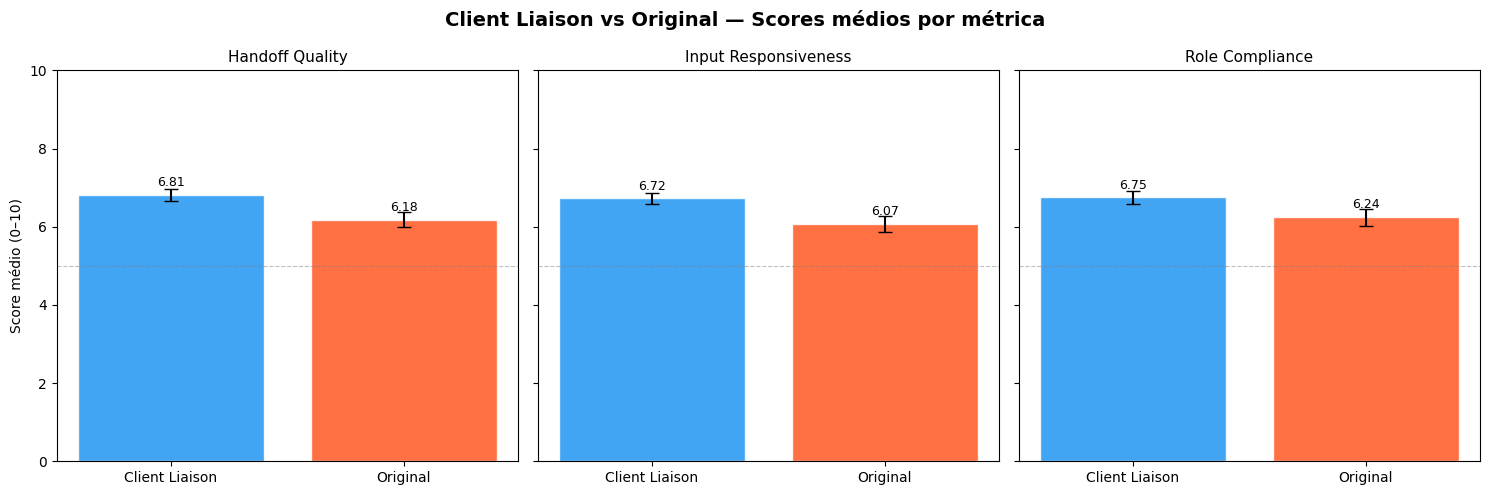

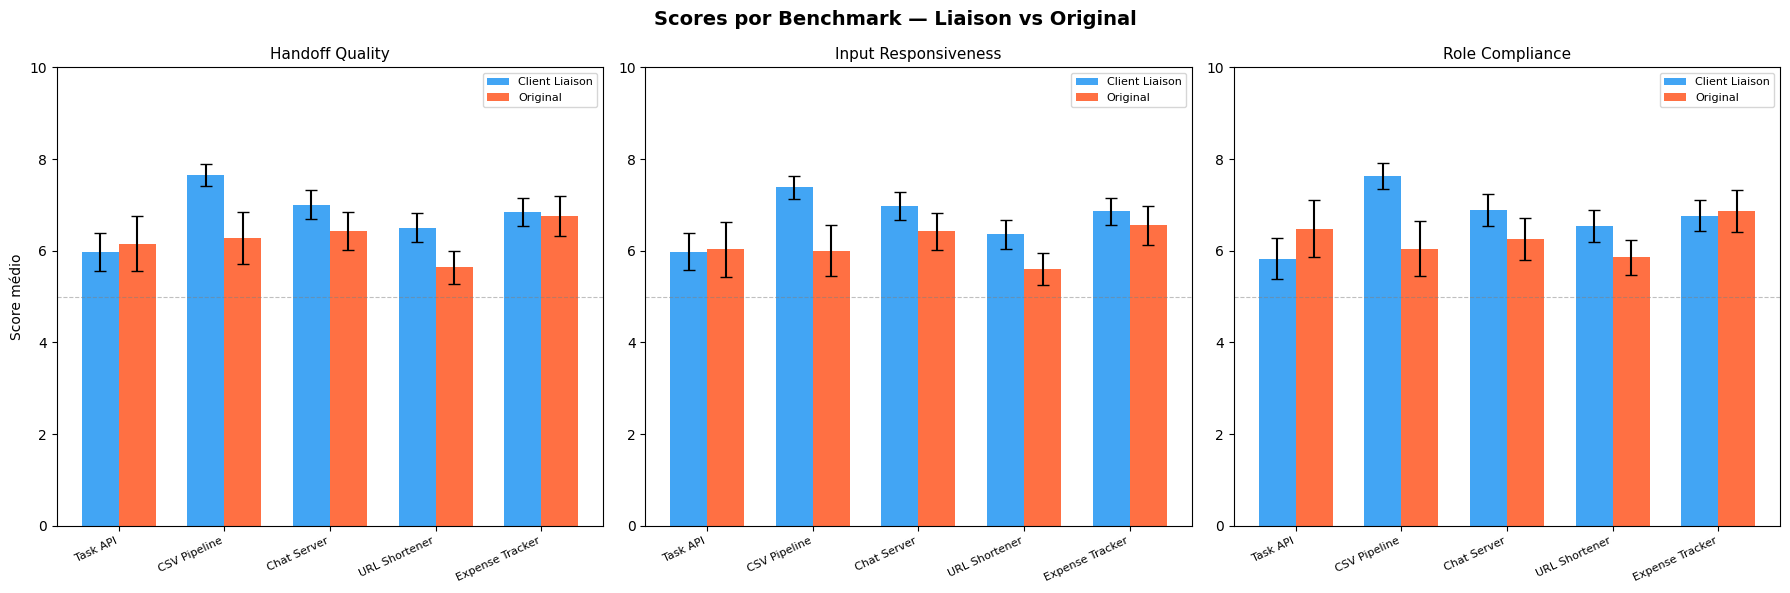

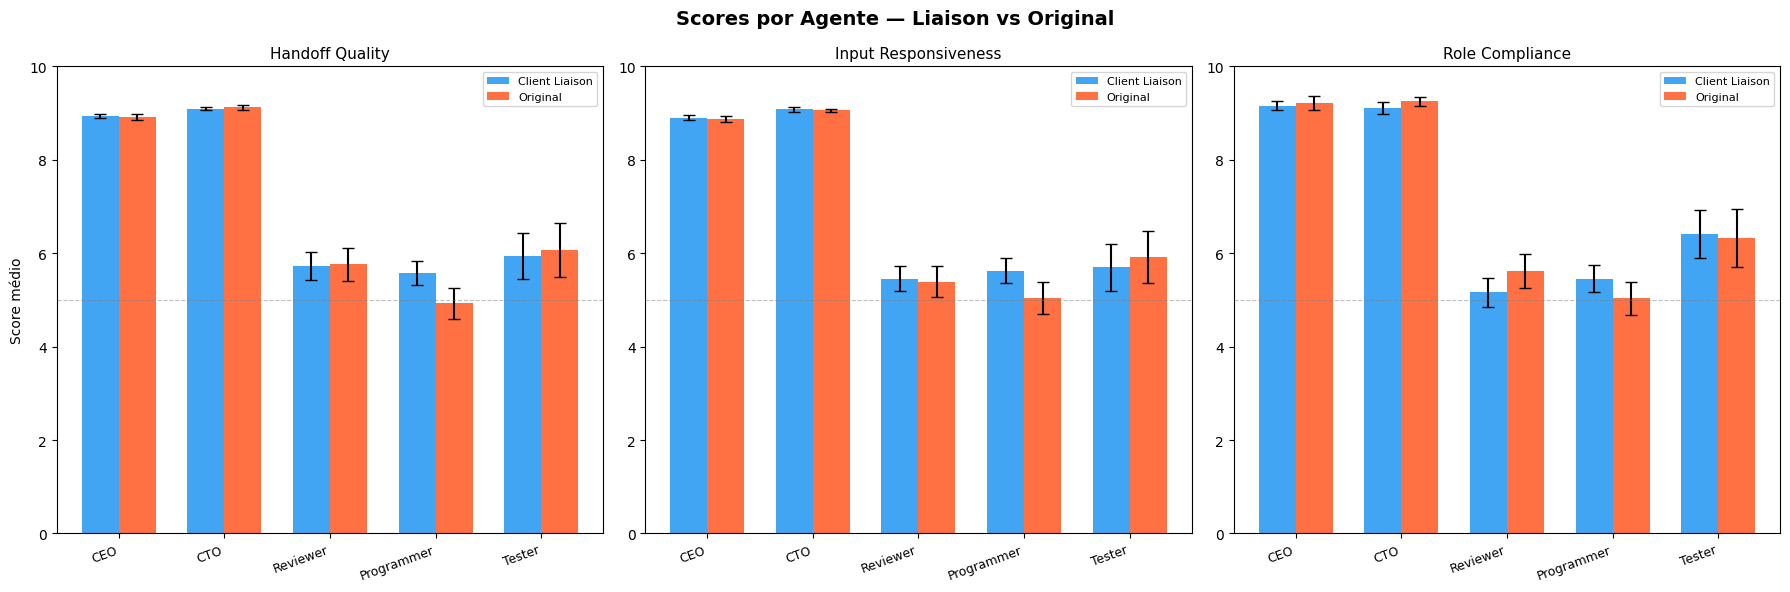

/tmp/ipykernel_11441/421292253.py:196: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


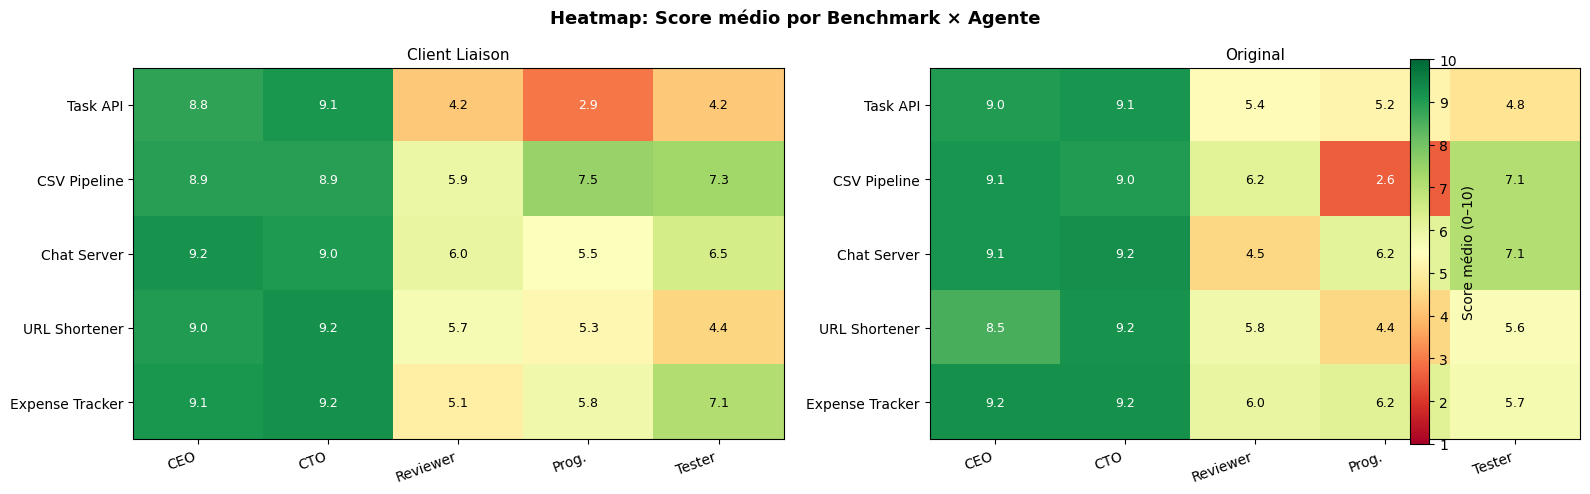

✅ 4 gráficos gerados e guardados.


In [175]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── 1. Preparação dos dados ──────────────────────────────────────────────────

# Normalizar nomes de scores (existem duplicados com maiúsculas/minúsculas)
score_rename = {
    'Handoff Quality': 'handoff_quality',
    'Responsiveness': 'input_responsiveness',
    'Role Compliance': 'role_compliance',
    'score1': None, 'score 2': None, 'score 3': None,  # descartar
}

feedback_clean = feedback_df.copy()
feedback_clean['score_name'] = feedback_clean['score_name'].map(
    lambda x: score_rename.get(x, x)
)
feedback_clean = feedback_clean[feedback_clean['score_name'].notna()]

METRICS = ['handoff_quality', 'input_responsiveness', 'role_compliance']
feedback_clean = feedback_clean[feedback_clean['score_name'].isin(METRICS)]

# Adicionar benchmark (tag) e run_group via thread_id
thread_to_group = {tid: grp for grp, tids in thread_groups.items() for tid in tids}

# Reconstruir mapa thread_id → benchmark a partir dos traces
thread_to_benchmark = (
    traces_raw[['thread_id', 'tags']]
    .dropna(subset=['thread_id', 'tags'])
    .assign(tags=lambda df: df['tags'].apply(
        lambda x: x[0] if isinstance(x, list) and len(x) > 0 else str(x)
    ))
    .drop_duplicates('thread_id')
    .set_index('thread_id')['tags']
    .to_dict()
)

feedback_clean['run_group'] = feedback_clean['thread_id'].map(thread_to_group)
feedback_clean['benchmark'] = feedback_clean['thread_id'].map(thread_to_benchmark)
feedback_clean['condition'] = feedback_clean['run_group'].apply(
    lambda x: 'Client Liaison' if isinstance(x, str) and x.startswith('client') else 'Original'
)
feedback_clean = feedback_clean.dropna(subset=['run_group', 'benchmark'])

BENCHMARKS = [
    'benchmark_task_api',
    'benchmark_csv_pipeline',
    'benchmark_chat_server',
    'benchmark_url_shortener',
    'benchmark_expense_tracker',
]
BENCH_LABELS = {
    'benchmark_task_api': 'Task API',
    'benchmark_csv_pipeline': 'CSV Pipeline',
    'benchmark_chat_server': 'Chat Server',
    'benchmark_url_shortener': 'URL Shortener',
    'benchmark_expense_tracker': 'Expense Tracker',
}
NODES_ORDER = ['Chief Executive Officer', 'Chief Technology Officer',
               'Code Reviewer', 'Programmer', 'Tester']
COLORS = {'Client Liaison': '#2196F3', 'Original': '#FF5722'}

# ── 2. Gráfico 1: Liaison vs Original — scores médios por métrica ────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
fig.suptitle('Client Liaison vs Original — Scores médios por métrica', fontsize=14, fontweight='bold')

for ax, metric in zip(axes, METRICS):
    grp = (
        feedback_clean[feedback_clean['score_name'] == metric]
        .groupby('condition')['score_value']
        .agg(['mean', 'sem'])
        .reindex(['Client Liaison', 'Original'])
    )
    bars = ax.bar(grp.index, grp['mean'], yerr=grp['sem'],
                  color=[COLORS[c] for c in grp.index],
                  capsize=5, alpha=0.85, edgecolor='white')
    ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Score médio (0–10)' if ax == axes[0] else '')
    ax.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, (_, row) in zip(bars, grp.iterrows()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
                f'{row["mean"]:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('scores_liaison_vs_original.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 3. Gráfico 2: Scores por benchmark (Liaison vs Original) ────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scores por Benchmark — Liaison vs Original', fontsize=14, fontweight='bold')

x = np.arange(len(BENCHMARKS))
width = 0.35

for ax, metric in zip(axes, METRICS):
    vals = {}
    errs = {}
    for cond in ['Client Liaison', 'Original']:
        sub = feedback_clean[
            (feedback_clean['score_name'] == metric) &
            (feedback_clean['condition'] == cond)
        ]
        means = [sub[sub['benchmark'] == b]['score_value'].mean() for b in BENCHMARKS]
        sems  = [sub[sub['benchmark'] == b]['score_value'].sem()  for b in BENCHMARKS]
        vals[cond] = means
        errs[cond] = sems

    ax.bar(x - width/2, vals['Client Liaison'], width, yerr=errs['Client Liaison'],
           label='Client Liaison', color=COLORS['Client Liaison'], capsize=4, alpha=0.85)
    ax.bar(x + width/2, vals['Original'],       width, yerr=errs['Original'],
           label='Original',       color=COLORS['Original'],       capsize=4, alpha=0.85)

    ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([BENCH_LABELS[b] for b in BENCHMARKS], rotation=25, ha='right', fontsize=8)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Score médio' if ax == axes[0] else '')
    ax.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scores_por_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 4. Gráfico 3: Scores por agente (node_id) ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Scores por Agente — Liaison vs Original', fontsize=14, fontweight='bold')

nodes_present = [n for n in NODES_ORDER if n in feedback_clean['node_id'].unique()]
x = np.arange(len(nodes_present))

for ax, metric in zip(axes, METRICS):
    vals = {}
    errs = {}
    for cond in ['Client Liaison', 'Original']:
        sub = feedback_clean[
            (feedback_clean['score_name'] == metric) &
            (feedback_clean['condition'] == cond)
        ]
        means = [sub[sub['node_id'] == n]['score_value'].mean() for n in nodes_present]
        sems  = [sub[sub['node_id'] == n]['score_value'].sem()  for n in nodes_present]
        vals[cond] = means
        errs[cond] = sems

    ax.bar(x - width/2, vals['Client Liaison'], width, yerr=errs['Client Liaison'],
           label='Client Liaison', color=COLORS['Client Liaison'], capsize=4, alpha=0.85)
    ax.bar(x + width/2, vals['Original'],       width, yerr=errs['Original'],
           label='Original',       color=COLORS['Original'],       capsize=4, alpha=0.85)

    ax.set_title(metric.replace('_', ' ').title(), fontsize=11)
    ax.set_xticks(x)
    short = {'Chief Executive Officer': 'CEO', 'Chief Technology Officer': 'CTO',
             'Code Reviewer': 'Reviewer', 'Programmer': 'Programmer', 'Tester': 'Tester'}
    ax.set_xticklabels([short.get(n, n) for n in nodes_present], rotation=20, ha='right', fontsize=9)
    ax.set_ylim(0, 10)
    ax.set_ylabel('Score médio' if ax == axes[0] else '')
    ax.axhline(5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('scores_por_agente.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 5. Gráfico 4: Heatmap — score médio por benchmark × agente ──────────────

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Heatmap: Score médio por Benchmark × Agente', fontsize=13, fontweight='bold')

for ax, cond in zip(axes, ['Client Liaison', 'Original']):
    sub = feedback_clean[feedback_clean['condition'] == cond]
    pivot = sub.groupby(['benchmark', 'node_id'])['score_value'].mean().unstack(fill_value=np.nan)
    pivot = pivot.reindex(index=BENCHMARKS, columns=nodes_present)
    pivot.index = [BENCH_LABELS[b] for b in BENCHMARKS]

    im = ax.imshow(pivot.values, cmap='RdYlGn', vmin=1, vmax=10, aspect='auto')
    ax.set_xticks(range(len(nodes_present)))
    short = {'Chief Executive Officer': 'CEO', 'Chief Technology Officer': 'CTO',
             'Code Reviewer': 'Reviewer', 'Programmer': 'Prog.', 'Tester': 'Tester'}
    ax.set_xticklabels([short.get(n, n) for n in nodes_present], rotation=20, ha='right')
    ax.set_yticks(range(len(BENCHMARKS)))
    ax.set_yticklabels(pivot.index)
    ax.set_title(cond, fontsize=11)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            val = pivot.values[i, j]
            if not np.isnan(val):
                ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                        color='black' if 3 < val < 8 else 'white')

plt.colorbar(im, ax=axes, fraction=0.02, label='Score médio (0–10)')
plt.tight_layout()
plt.savefig('heatmap_benchmark_agente.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ 4 gráficos gerados e guardados.")

In [176]:
# Ver todos os thread IDs que existem no Opik
all_opik_threads = set(traces_raw['thread_id'].dropna().unique())
mapped_cl = {tid for tid, grp in thread_to_group.items() if grp.startswith('client')}
mapped_orig = {tid for tid, grp in thread_to_group.items() if grp.startswith('original')}

print(f"Total threads no Opik: {len(all_opik_threads)}")
print(f"Client Liaison mapeadas: {len(mapped_cl)}")
print(f"Original mapeadas: {len(mapped_orig)}")
print(f"\nClient Liaison que existem no Opik: {len(all_opik_threads & mapped_cl)}")
print(f"Original que existem no Opik: {len(all_opik_threads & mapped_orig)}")

print("\n--- Todos os thread IDs do Opik ---")
for t in sorted(all_opik_threads):
    grp = thread_to_group.get(t, '❌ NÃO MAPEADO')
    print(f"  {t}  →  {grp}")

Total threads no Opik: 223
Client Liaison mapeadas: 31
Original mapeadas: 24

Client Liaison que existem no Opik: 31
Original que existem no Opik: 24

--- Todos os thread IDs do Opik ---
  00c0722d-bea3-4a04-aff1-6cb30ce5e18f  →  ❌ NÃO MAPEADO
  0270e3d0-f8f1-4ca9-b236-2ef22c8bfc86  →  ❌ NÃO MAPEADO
  0482628a-f785-46d3-b954-6e4c980123a1  →  ❌ NÃO MAPEADO
  050a6bdc-6c14-4b0e-a059-8a4d406558fd  →  client_liaison_run_5
  058a71b2-9cff-42ba-84d2-f36710fee04b  →  ❌ NÃO MAPEADO
  0865c9a7-874c-4692-9549-9c9d45ec62b4  →  ❌ NÃO MAPEADO
  089782e8-557c-46e8-90be-bde8e97e3bdf  →  ❌ NÃO MAPEADO
  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  →  client_liaison_run_6
  0960924a-a112-4368-9e32-0d2fd840519d  →  ❌ NÃO MAPEADO
  09935ff6-fd34-4926-9ba0-7e1ca499249f  →  ❌ NÃO MAPEADO
  09b7be40-32a1-4858-acee-3cd96a87f401  →  ❌ NÃO MAPEADO
  09bb6ee3-e400-4672-88d6-42eca4f65f1f  →  ❌ NÃO MAPEADO
  0a9b1a87-41e4-477c-9dd6-20584d7b9a0e  →  ❌ NÃO MAPEADO
  0cf2068c-46e5-420d-ad73-4725a900b9a2  →  ❌ NÃO MAPEADO
 

In [177]:
unmapped = [
    '092ab63d-3a82-4b5f-9d80-0e8f385a57c5',
    '9b228c5c-c275-4bc2-adf7-d26bc1441b87',
    'b184b195-2124-4f13-b5ad-c25669f95993',
    'b2b8f898-f3f6-42b3-92be-7e1b6643835e',
    'c98e0afa-94d3-40ed-8952-d180333f06d4',
    'dbed0c80-02de-4479-91d3-fdb6332e3382',
]

for tid in unmapped:
    sub = traces_raw[traces_raw['thread_id'] == tid][['thread_id', 'tags', 'metadata.node_id']].head(3)
    print(sub.to_string())
    print()

                                thread_id                      tags metadata.node_id
158  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  [benchmark_csv_pipeline]           Tester
159  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  [benchmark_csv_pipeline]    Code Reviewer
160  092ab63d-3a82-4b5f-9d80-0e8f385a57c5  [benchmark_csv_pipeline]       Programmer

                                thread_id                         tags metadata.node_id
164  9b228c5c-c275-4bc2-adf7-d26bc1441b87  [benchmark_expense_tracker]           Tester
165  9b228c5c-c275-4bc2-adf7-d26bc1441b87  [benchmark_expense_tracker]    Code Reviewer
166  9b228c5c-c275-4bc2-adf7-d26bc1441b87  [benchmark_expense_tracker]       Programmer

                               thread_id                  tags          metadata.node_id
78  b184b195-2124-4f13-b5ad-c25669f95993  [benchmark_task_api]             Code Reviewer
85  b184b195-2124-4f13-b5ad-c25669f95993  [benchmark_task_api]                Programmer
90  b184b195-2124-4f13-b5ad-c25669f9599

## How to select fields

Use `fetch_traces(filter_string=...)` or `fetch_threads(filter_string=...)` with OQL filters.
Examples:
- `thread_id = "thread_123"`
- `metadata.agent_role = "Client Liaison"`
- `feedback_scores.Responsiveness > 0.8`
- `tags contains "production"`

To choose columns, edit `TRACE_COLUMNS` and `THREAD_COLUMNS`, then rerun the selection cells.